# Load pytorch model

In [1]:
import os
import time
import requests
from tqdm import tqdm

import diffusers

from DeepCache import DeepCacheSDHelper

mode = 32
deep_cache = False

if mode != 16:
    # Verify checkpoints/model-16 folder exists
    if not os.path.exists("/workspace/checkpoints/model-16"):
        raise ValueError("checkpoints/model-16 folder does not exist")

/opt/conda/envs/triton/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch
import tensorrt as trt
import onnxruntime

print(f"PyTorch version: {torch.__version__}")
print(f"TensorRT version: {trt.__version__}")
print(f"cudnn version: {torch.backends.cudnn.version()}")
print(f"CUDA version: {torch.version.cuda}")

try:
    gpu_info = onnxruntime.get_device()
    print(f"ONNX GPU support: {gpu_info}")
except AttributeError:
    print("ONNX runtime does not support GPU or the method get_device() is not available.")

if not torch.cuda.is_available():
    raise SystemError("GPU device not found. PyTorch requires a GPU to run this code.")
else:
    print(f"Found GPU device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA capability: {torch.cuda.get_device_capability(0)}")

PyTorch version: 2.5.0.dev20240704
TensorRT version: 10.1.0
cudnn version: 90100
CUDA version: 12.4
ONNX GPU support: GPU
Found GPU device: NVIDIA A100 80GB PCIe
CUDA capability: (8, 0)


In [3]:
def download_checkpoint(download_url, checkpoint_file):
    if os.path.exists(checkpoint_file):
        print(f"{checkpoint_file} already exists. Skipping download.")
        return

    folder, filename = os.path.split(checkpoint_file)
    os.makedirs(folder, exist_ok=True)
    with requests.get(download_url, stream=True) as response:
        total_size = int(response.headers.get("content-length", 0))
        with open(checkpoint_file, "wb") as file_stream, tqdm(
            desc=checkpoint_file,
            total=total_size,
            unit="B",
            unit_scale=True,
            unit_divisor=1024,
        ) as progress_bar:
            for data in response.iter_content(chunk_size=1024):
                file_stream.write(data)
                progress_bar.update(len(data))

    print("Download completed successfully.")
download_checkpoint("https://civitai.com/api/download/models/173961", "checkpoints/AnimeV3.safetensors")

checkpoints/AnimeV3.safetensors already exists. Skipping download.


In [4]:
from diffusers import (
    DPMSolverMultistepScheduler,
    EulerDiscreteScheduler,
    EulerAncestralDiscreteScheduler
)

def set_scheduler(scheduler_name: str, config):
    if scheduler_name == "dpm++2m_karras":
        scheduler = DPMSolverMultistepScheduler.from_config(
            config, use_karras_sigmas=True
        )
    elif scheduler_name == "euler":
        scheduler = EulerDiscreteScheduler.from_config(
            config
        )
    elif scheduler_name == "euler_ancestral":
        scheduler = EulerAncestralDiscreteScheduler.from_config(
            config
        )
    else:
        raise ValueError(f"Unknown scheduler: {scheduler_name}")

    return scheduler

txt2img_pipe = diffusers.StableDiffusionXLPipeline.from_single_file(
    "checkpoints/AnimeV3.safetensors",
    use_safetensors=True,
    torch_dtype=torch.float16 if mode == 16 else torch.float32
)
scheduler_name = "dpm++2m_karras"
# scheduler_name = "euler"
# scheduler_name = "euler_ancestral"
txt2img_pipe.scheduler = set_scheduler(
    scheduler_name, txt2img_pipe.scheduler.config
)
txt2img_pipe.to("cuda")

if deep_cache:
    print("Enabling DeepCache")
    helper = DeepCacheSDHelper(txt2img_pipe)
    helper.set_params(cache_interval=3, cache_branch_id=0)
    helper.enable()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]Some weights of the model checkpoint were not used when initializing CLIPTextModel: 
 ['text_model.embeddings.position_ids']
Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  3.50it/s]


In [5]:
torch.manual_seed(42)
prompt = "sailing ship in storm by Leonardo da Vinci"
negative_prompt = "out of frame, nude, duplicate, watermark, signature, mutated, text, blurry, worst quality, low quality, artificial, texture artifacts, jpeg artifacts"
t1 = time.time()
image = txt2img_pipe(prompt=prompt, negative_prompt=negative_prompt, num_inference_steps=25, 
                     guidance_scale=7, width=1024, height=1024, 
                     num_images_per_prompt = 1).images[0]
time.time() - t1

  0%|          | 0/25 [00:00<?, ?it/s]

100%|██████████| 25/25 [00:16<00:00,  1.52it/s]


17.185094594955444

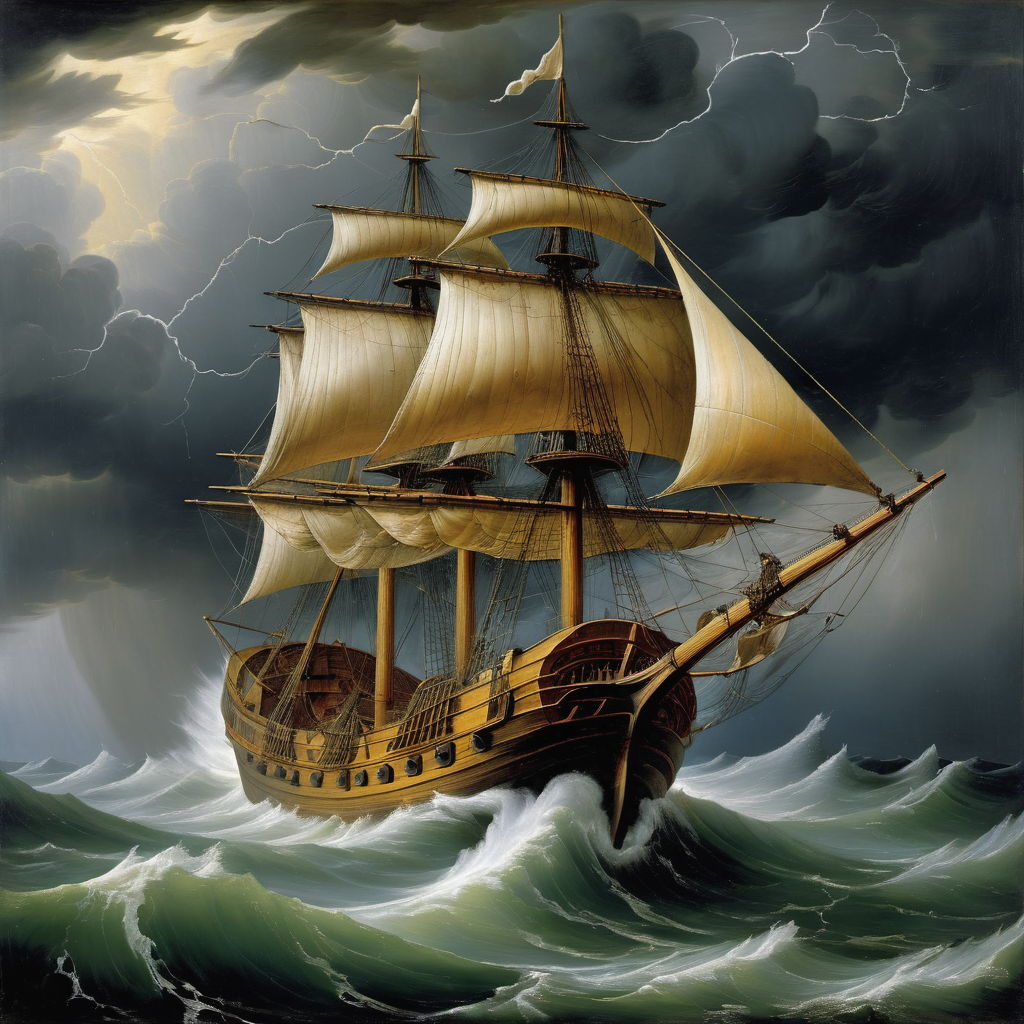

In [6]:
image

In [7]:
import shutil

path = "checkpoints/model-16" if mode == 16 else "checkpoints/model"

txt2img_pipe.save_pretrained(path, safe_serialization=True, torch_dtype=torch.float16 if mode == 16 else torch.float32)

if mode != 16:
    # Copy file checkpoints/model-16/unet/diffusion_pytorch_model.fp16.safetensors to checkpoints/model/unet/diffusion_pytorch_model.fp16.safetensors
    shutil.copy("checkpoints/model-16/unet/diffusion_pytorch_model.safetensors", "checkpoints/model/unet/diffusion_pytorch_model.fp16.safetensors")

    # Copy file checkpoints/model-16/vae/diffusion_pytorch_model.fp16.safetensors to checkpoints/model/vae/diffusion_pytorch_model.fp16.safetensors
    shutil.copy("checkpoints/model-16/vae/diffusion_pytorch_model.safetensors", "checkpoints/model/vae/diffusion_pytorch_model.fp16.safetensors")